In [1]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import numpy as np
import torch
import tensorly as tl
from tensorly.decomposition import parafac
import sparse
import pickle
import os
import numpy.random as rn
import scipy.stats as st
from tensorly.cp_tensor import CPTensor
import matplotlib.pyplot as plt

from own_implementation import BPTF as BPTF
import bptf

# Please run everything up to the first bptf fit
# Thereafter, run each following cell on their own

<IPython.core.display.Javascript object>

Kernel is restarting...


# Helper functions

In [2]:
def generate(shp=(30, 30, 20, 10), K=5, alpha=0.1, beta=0.1):
    """Generate a count tensor from the BPTF model.

    PARAMS:
    shp -- (tuple) shape of the generated count tensor
    K -- (int) number of latent components
    alpha -- (float) shape parameter of gamma prior over factors
    beta -- (float) rate parameter of gamma prior over factors

    RETURNS:
    Mu -- (np.ndarray) true Poisson rates
    Y -- (np.ndarray) generated count tensor
    """
    Theta_DK_M = [rn.gamma(alpha, 1./beta, size=(D, K)) for D in shp]
    Theta_DK_M = [torch.tensor(factor) for factor in Theta_DK_M]
    Mu = tl.cp_to_tensor(CPTensor((None, Theta_DK_M)))
    assert Mu.shape == shp
    Y = rn.poisson(Mu)
    return Mu, Y

# Load data

In [3]:
use_existing_data = True

# for the first bptf.fit:
# using seed 100 causes the assert delta >= 0 to trip
# but using seed 0 doesn't
# please swap between the 2 seeds to get the 2 different types of assertion errors in the other cells
rn.seed(100)
device = 'cuda'
num_months = 12

if use_existing_data:
    assert os.path.exists('sptensor.pkl'), 'No such file.'
    with open('sptensor.pkl', 'rb') as f:
        data = pickle.load(f)
    data = data[:, :, :, :num_months, :]
    data = torch.tensor(data.todense(), dtype=torch.float64, device=device)
else:
    data = generate(shp=(200, 200, 20, num_months, 3), K=10)[1]
    data = torch.tensor(data, dtype=torch.float64, device=device)

# Building mask (base example)

In [4]:
mask = np.ones(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, 1] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

# Fit model

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2819991497.2367806, 5179203.48335905, 5395177.599166707, 6057733.765861358, 7099889.159502756, 8234107.426698659, 9321191.540086865, 10105383.133063236, 10569493.899125425, 10859295.911356064, 11065737.686025668, 11221667.207332952, 11342963.914902864, 11448659.643478524, 11530405.5581504, 11591653.92894248, 11642239.061075946, 11687899.268802958, 11727503.397139989, 11761399.87086098, 11790807.92385794, 11816319.645938387, 11838439.659690611, 11857696.842749318, 11874537.746785179, 11889441.928202223, 11902936.402740853, 11915129.698049126, 11926093.175289303, 11935939.759648241, 11944708.074569691, 11952462.494601592, 11959269.158465615, 11965245.048429415, 11970524.574541574, 11975243.288251422, 11979520.996998334, 11983404.572944857, 11987273.497433897, 11991494.736412175, 11995200.47915723, 11998244.31217547, 12001039.334856438, 12003728.489610692, 12006315.112252861, 12008730.71121324

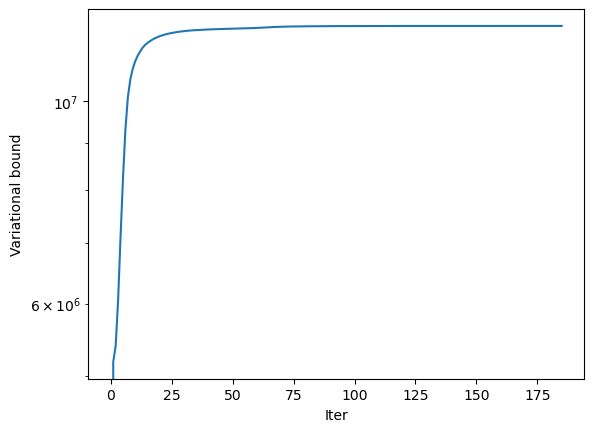

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [5]:
n_components = 50
max_iter = 500
tol = 1e-6
verbose = False

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# Mask with last mode completely masked

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2748997840.530172, 5303238.616371926, 5426548.0139268385, 5840099.42844965, 6794693.490245052, 8024666.781883898, 9092745.040683221, 9873267.215479046, 10417230.312035574, 10769082.321898855, 11010961.957495466, 11189996.83910974, 11325898.06828211, 11432528.495434856, 11518604.334110575, 11588504.341703808, 11644525.350399591, 11690227.148998648, 11730985.998561755, 11764067.659348903, 11792567.446715286, 11818937.783588221, 11843781.997254292, 11866649.586396996, 11887130.381072935, 11905651.928229477, 11922809.493185868, 11938916.984370742, 11953991.662135914, 11968016.596619174, 11981036.375598654, 11993251.516822647, 12004761.054330472, 12015636.071722822, 12025906.877018074, 12035657.917301662, 12045037.419624384, 12054155.56281305, 12062876.691966506, 12071112.611548759, 12078779.433873089, 12085749.098851392, 12091999.685176617, 12097596.98125866, 12102615.472197419, 12107123.450360

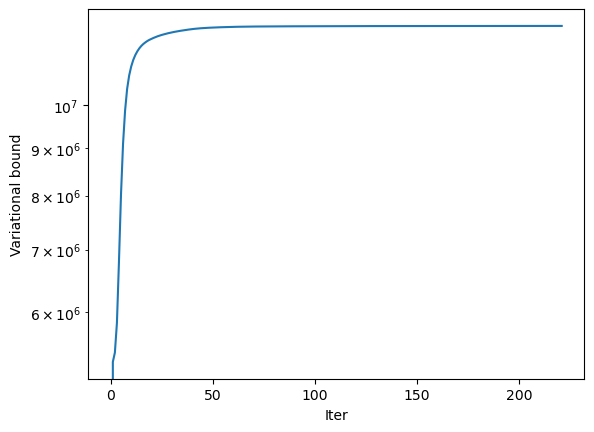

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [6]:
mask = np.ones(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, :] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# Mask with the 1st and 3rd indices masked

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2769923444.890541, 5732570.231606461, 6156638.79355664, 6617379.053376463, 7680845.838968413, 9019261.535368577, 10269376.511212962, 11161894.108486405, 11693643.536036354, 12027629.392416818, 12266014.839041732, 12441528.99869754, 12574469.37133636, 12680882.315543126, 12769789.039698614, 12845780.014648829, 12909087.028985316, 12962762.543580191, 13008762.678341735, 13047721.957248516, 13080097.475509563, 13107169.173316337, 13130474.086349906, 13150465.56067377, 13167094.185079528, 13181434.11140184, 13194261.581681421, 13206168.67175628, 13217457.105854077, 13228138.976317039, 13238025.458110256, 13247004.485767996, 13255105.931306416, 13262446.060635982, 13269147.822368177, 13275359.350253208, 13281215.48745412, 13286826.739925, 13292256.135517348, 13297524.9759689, 13302635.858148383, 13307597.620023752, 13312452.415831165, 13317233.578470277, 13321956.176775798, 13326570.70339895, 13

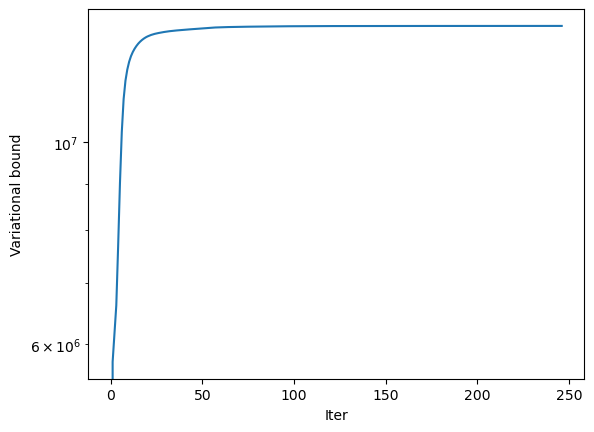

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [7]:
mask = np.ones(data.shape)
# april is set to missing
mask[:, :, :, 3, [0, 2]] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# Mask with only diagonals masked

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2970945373.8978953, 5936882.004244037, 6043062.74803394, 6380763.629807367, 7388817.832277621, 8686888.581987863, 9938413.293595133, 10929412.547717165, 11587189.45582298, 11995093.254993068, 12264091.500207074, 12464265.603811532, 12611579.476806581, 12715300.020948032, 12797829.348354476, 12866147.661467561, 12923877.219465032, 12973204.567426281, 13014735.940357678, 13049738.91327812, 13079245.035462858, 13104190.94704532, 13125444.805267213, 13143555.014010474, 13158937.608282754, 13172058.981781045, 13183392.997110542, 13193325.213448497, 13202199.65634854, 13210376.30356468, 13218057.631536514, 13225115.71144256, 13231605.185647631, 13237494.018654639, 13242803.284445016, 13247607.881199636, 13252013.951076211, 13256101.084822802, 13259915.42178315, 13263498.989502657, 13266896.79639948, 13270115.782718442, 13273174.693836156, 13276094.009479847, 13278882.842250075, 13281551.239251848

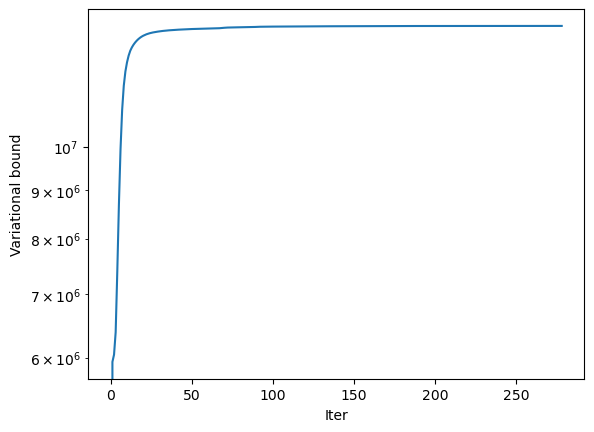

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [8]:
mask = np.ones(data.shape)

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# No mask

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2932957233.0596113, 8326696.348812046, 8573768.264700074, 9524565.42631607, 11372653.26995852, 13576383.423067557, 15498855.92020683, 16717676.96661463, 17460436.457744572, 17918738.01033864, 18198306.244095627, 18387028.15233719, 18525672.829018064, 18628664.733792618, 18708423.470951226, 18773822.185539726, 18828448.765821274, 18873438.347117603, 18911080.399761926, 18943269.56107805, 18971223.080327764, 18995953.939901087, 19018404.72281631, 19038461.31551992, 19055282.485217966, 19069590.467480518, 19081790.378126323, 19092057.87547362, 19100682.050384928, 19108050.94042775, 19114569.60100624, 19120444.899956718, 19125939.449165277, 19131073.93338314, 19135838.60838939, 19140395.533476118, 19144910.41848373, 19149215.324599538, 19152945.877932295, 19156024.575777054, 19158637.818118468, 19160931.9400103, 19163021.698218685, 19164938.516741473, 19166699.781413063, 19168354.36346669, 1916

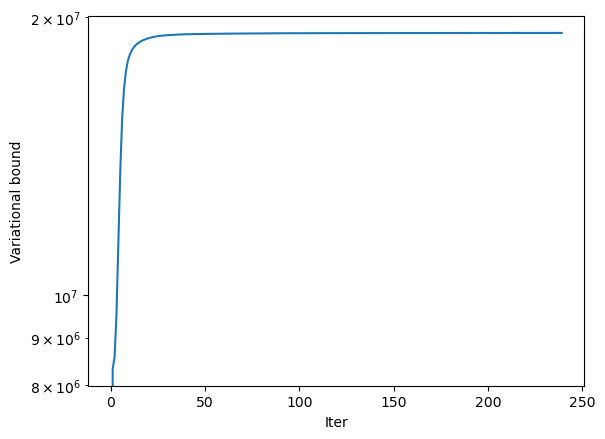

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [9]:
BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = None, max_iter = max_iter, verbose=verbose, tol=tol)

In [10]:
with torch.no_grad():
    # torch.cuda.synchronize()
    b1 = BPTF_model._elbo(data, mask)
    torch.cuda.synchronize()
    b2 = BPTF_model._elbo(data, mask)
print((b2 - b1) * 1e8)               # absolute change in “ULPs”

tensor(0., device='cuda:0')
